# ALA: the Ramachandran free energy surface

The joint PMF over (phi, psi) -- the surface the one-dimensional page projects away.

**Why the 2D version is the honest one.** Projecting onto phi alone merges every psi at a given
phi into one number. Two basins that differ only in psi become one feature, and a barrier that
exists only along psi disappears. The 1D PMF is a legitimate object; it is just a different one,
and this surface shows what it averaged over.

**The grid is coarser than it looks.** 72 x 72 is 5184 bins, and a run populating 1800 of them is
leaving two thirds empty. Those stay NaN.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parents[1] / "_analysis"))   # docs/tutorial/_analysis

import numpy as np
import matplotlib.pyplot as plt
import mdtraj as md
import tutorial_data as td

# Where the runs are. NOT defaulted: see docs/tutorial/_analysis/tutorial_data.py.
# The resolved path is deliberately NOT printed. These notebooks are committed WITH
# their outputs, so an echoed absolute path would put one machine's layout into a
# published file -- which this project forbids, and which executing a notebook turns
# from a parameter into a stored string.
print("tutorial runs:", "found" if td.runs_root().is_dir() else "MISSING")

tutorial runs: found


In [2]:
cmd = td.solute("ALA-1us", stride=1)
_, phi = md.compute_phi(cmd)
_, psi = md.compute_psi(cmd)

x, y, F = td.pmf2d(phi[:, 0], psi[:, 0], bins=72)
print(f"{cmd.n_frames} frames, {np.isfinite(F).sum()} populated bins of {F.size}, "
      f"span {np.nanmax(F):.1f} kJ/mol")

100000 frames, 1837 populated bins of 5184, span 17.5 kJ/mol


Text(0.5, 1.0, 'Alanine dipeptide, 1 us cMD\n1837 of 5184 bins populated')

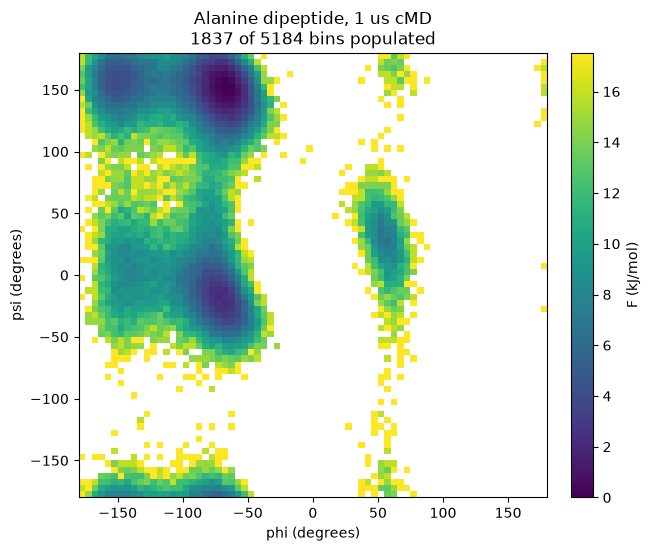

In [3]:
fig, ax = plt.subplots(figsize=(6.4, 5.4), layout="constrained")
mesh = ax.pcolormesh(np.rad2deg(x), np.rad2deg(y), F.T, cmap="viridis", shading="auto",
                     vmin=0, vmax=np.nanpercentile(F, 98))
fig.colorbar(mesh, ax=ax, label="F (kJ/mol)")
ax.set_xlabel("phi (degrees)"); ax.set_ylabel("psi (degrees)")
ax.set_title(f"Alanine dipeptide, 1 us cMD\n{np.isfinite(F).sum()} of {F.size} bins populated")

## The cold REST2 rung, for comparison

Same surface from state 0 of the ladder. With far fewer frames the empty-bin fraction is much
higher, which is the thing to look at first: a surface with a sparse grid is not a smoother
surface, it is a less determined one.

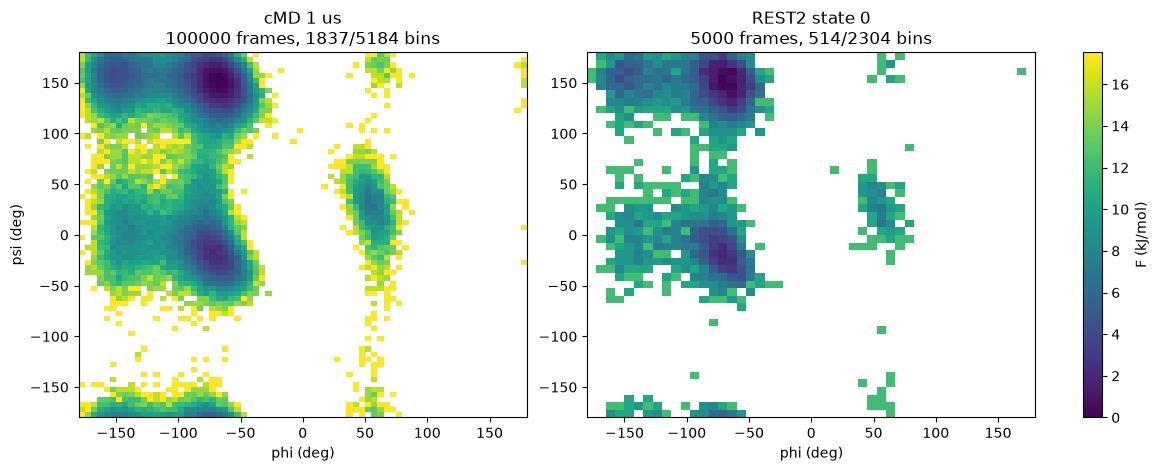

In [4]:
rest2 = td.solute("ALA-REST2", trajectory="REST2-run1/solute_state0_prod1.nc")
_, phi_r = md.compute_phi(rest2)
_, psi_r = md.compute_psi(rest2)
xr, yr, Fr = td.pmf2d(phi_r[:, 0], psi_r[:, 0], bins=48)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), layout="constrained")
for axis, (xx, yy, FF, title, n) in zip(axes, [
        (x, y, F, "cMD 1 us", cmd.n_frames), (xr, yr, Fr, "REST2 state 0", rest2.n_frames)]):
    m = axis.pcolormesh(np.rad2deg(xx), np.rad2deg(yy), FF.T, cmap="viridis", shading="auto",
                        vmin=0, vmax=np.nanpercentile(F, 98))
    axis.set_title(f"{title}\n{n} frames, {np.isfinite(FF).sum()}/{FF.size} bins")
    axis.set_xlabel("phi (deg)")
axes[0].set_ylabel("psi (deg)")
fig.colorbar(m, ax=axes, label="F (kJ/mol)")

Note the two panels use DIFFERENT bin counts (72 and 48). That is deliberate and it is also a
warning: a PMF's appearance depends on the binning, so two surfaces are only comparable at the
same grid. Here the coarser grid is used for the shorter run because a 72 x 72 grid over 5000
frames is mostly empty -- and the right response to a sparse grid is a coarser one, not a
smoother colour map.